# Setup

This project requires Python 3.7 or above:

In [2]:
import sys
assert sys.version_info >= (3, 7)

And TensorFlow ≥ 2.8:

In [3]:
import sys
print(sys.executable)

c:\Users\USER\envs\mydl_env\Scripts\python.exe


In [4]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/rnn` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [6]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "rnn"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [7]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.


# Basic RNNs

Let's download the ridership data from the ageron/data project. It originally comes from Chicago's Transit Authority, and was downloaded from the [Chicago's Data Portal](https://homl.info/ridership).

**Warning**: in recent Keras versions, `get_file()` now wraps the extracted directory inside a directory whose name ends with `_extracted`, so the following code checks for that:

In [8]:
filepath = tf.keras.utils.get_file(
    "ridership.tgz",
    "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir=".",
    extract=True
)
if "_extracted" in filepath:
    ridership_path = Path(filepath) / "ridership"
else:
    ridership_path = Path(filepath).with_name("ridership")

In [9]:
import pandas as pd
from pathlib import Path

path = ridership_path / "CTA_-_Ridership_-_Daily_Boarding_Totals.csv" 

df = pd.read_csv(path, parse_dates=["service_date"]) 

df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names

df = df.sort_values("date").set_index("date")

df = df.drop("total", axis=1)  # no need for total, it's just bus + rail

df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


In [10]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Let's look at the first few months of 2019 (note that Pandas treats the range boundaries as inclusive):

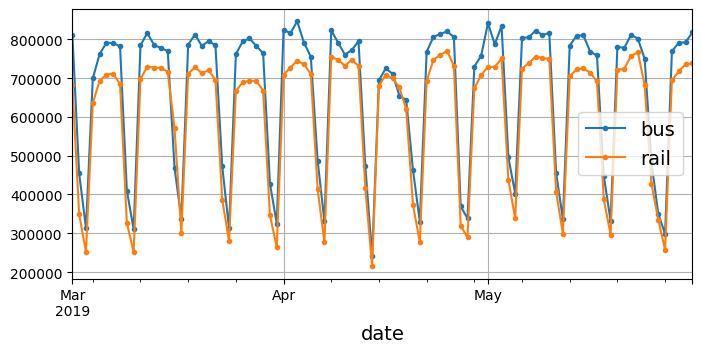

In [11]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
# save_fig("daily_ridership_plot")  # extra code – saves the figure for the book
plt.show()

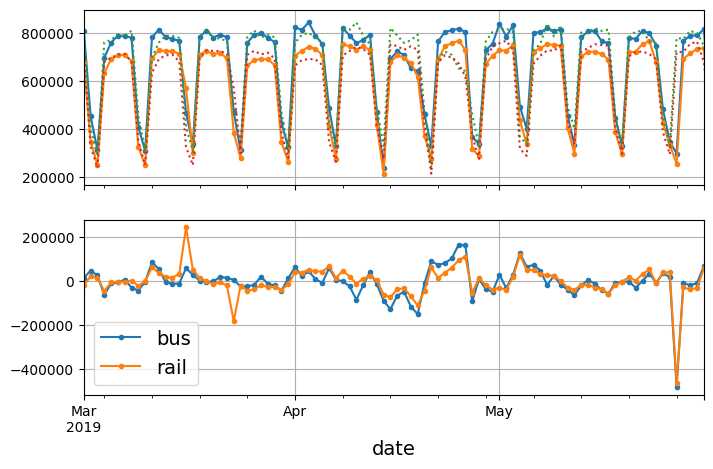

In [12]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
# İzah: "df" adlı məlumat cədvəlindən "bus" və "rail" sütunlarını götür,7 günlük fərq (differensial) hesabla və 2019 Mart - May ayları arasını seç.

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
# İzah: 2 sətir və 1 sütundan ibarət qrafik sahəsi yaradır.  sharex=True - x oxunu paylaşır, figsize=(8,5) - ölçüsü təyin edir.

df.plot(ax=axs[0], legend=False, marker=".")                        # original time series
# İzah: Birinci qrafikdə (axs[0]) orijinal zaman seriyasını çəkir. marker="." - hər nöqtəni nöqtə ilə göstərir, legend=False - xülasə göstərmir.

df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
# İzah: Eyni qrafikə (axs[0]) 7 gün geri sürüşdürülmüş (shift) məlumatı əlavə edir. linestyle=":" - nöqtəli xətt, grid=True - tor xətləri göstərir.

diff_7.plot(ax=axs[1], grid=True, marker=".")                         # 7-day difference time series
# İzah: İkinci qrafikdə (axs[1]) 7 günlük fərq seriyasını çəkir.  marker="." - nöqtə işarəsi, grid=True - tor xətləri.

axs[0].set_ylim([170_000, 900_000])                                    # extra code – beautifies the plot
# İzah: Birinci qrafikin y oxu həddini 170,000 - 900,000 arası təyin edir.

# save_fig("differencing_plot")                                           # extra code – saves the figure for the book
# İzah: Qrafiki "differencing_plot" adı ilə yaddaşa yazır (kitab üçün).

plt.show()
# İzah: Qrafiki göstərir.

In [13]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

# İzah: "df" adlı məlumat cədvəlindən 25 May 2019 - 27 May 2019 tarixləri arasındakı sətirləri seçir, bu sətirlərdən "day_type" 
# sütununu götürür və nəticəni siyahıya (list) çevirir.

['A', 'U', 'U']

Mean absolute error (MAE), also called mean absolute deviation (MAD):

In [14]:
df[["bus", "rail"]]["2019-03":"2019-05"].head(8)

,bus,rail
date,,
2019-03-01,812238,682969
2019-03-02,454119,349392
2019-03-03,313539,252150
2019-03-04,699086,635353
2019-03-05,761781,692945
2019-03-06,790908,708876
2019-03-07,790299,711428
2019-03-08,781577,684186


In [15]:
diff_7.head(8)   # 8 de 781577 - 812238 = -30661 

,bus,rail
date,,
2019-03-01,13927.0,-20019.0
2019-03-02,47280.0,21213.0
2019-03-03,25171.0,11672.0
2019-03-04,-63771.0,-45491.0
2019-03-05,-11268.0,-6517.0
2019-03-06,-6892.0,-2951.0
2019-03-07,6379.0,-3272.0
2019-03-08,-30661.0,1217.0


In [16]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

Mean absolute percentage error (MAPE):

In [17]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
targets = df[["bus", "rail"]]["2019-03":"2019-05"]

(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Now let's look at the yearly seasonality and the long-term trends:

**Warning**: Pandas' API to compute the mean for each month has changed quite a bit, so the code below tries the newest API, and falls back to an older API, and if that also fails, it falls back to the code in the book.

In [18]:
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
df_monthly

,bus,rail
date,,
2001-01-31,807190.580645,474591.419355
2001-02-28,848889.000000,488188.178571
2001-03-31,865392.419355,498825.096774
2001-04-30,835126.366667,490444.533333
2001-05-31,862701.419355,507862.258065
...,...,...
2021-07-31,342101.096774,257660.193548
2021-08-31,353215.516129,260038.548387
2021-09-30,401958.833333,299608.366667


In [19]:
period = slice("2001", "2019")  # 2001-2019 arası dövrü təyin edir
period

slice('2001', '2019', None)

In [20]:
df_monthly.loc[period].head(13)


,bus,rail
date,,
2001-01-31,807190.580645,474591.419355
2001-02-28,848889.000000,488188.178571
2001-03-31,865392.419355,498825.096774
2001-04-30,835126.366667,490444.533333
2001-05-31,862701.419355,507862.258065
2001-06-30,833149.033333,519549.900000
2001-07-31,791519.258065,516928.967742
2001-08-31,795070.580645,516604.387097
2001-09-30,830298.400000,491522.833333


In [21]:
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
rolling_average_12_months.head(13)

,bus,rail
date,,
2001-01-31,NaN,NaN
2001-02-28,NaN,NaN
2001-03-31,NaN,NaN
2001-04-30,NaN,NaN
2001-05-31,NaN,NaN
2001-06-30,NaN,NaN
2001-07-31,NaN,NaN
2001-08-31,NaN,NaN
2001-09-30,NaN,NaN


In [22]:
period = slice("2001", "2019")  # 2001-2019 arası dövrü təyin edir

try:
    df_monthly = df.select_dtypes(include="number").resample('ME').mean()  # Sayısal sütunları seç, aylıq ortalamaya çevir ('ME' - ay sonu)
    rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()  # Seçilmiş dövr üçün 12 aylıq hərəkətli ortalama hesabla
except ValueError as ex:
    try:
        df_monthly = df.select_dtypes(include="number").resample('M').mean()          
        # Əgər 'ME' işləməsə(verisyasa gore), 'M' ilə aylıq ortalamaya çevir
        rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()  # Yenə 12 aylıq hərəkətli ortalama hesabla
    except ValueError as ex:
        df_monthly = df.resample('M').mean()  # Əgər select_dtypes da işləməsə, bütün sütunlarla aylıq ortalama hesabla
        rolling_average_12_months = df_monthly[period].rolling(window=12).mean()  # Yenidən 12 aylıq hərəkətli ortalama

print(df_monthly.head(5))
print(rolling_average_12_months.head(5))

                      bus           rail
date                                    
2001-01-31  807190.580645  474591.419355
2001-02-28  848889.000000  488188.178571
2001-03-31  865392.419355  498825.096774
2001-04-30  835126.366667  490444.533333
2001-05-31  862701.419355  507862.258065
            bus  rail
date                 
2001-01-31  NaN   NaN
2001-02-28  NaN   NaN
2001-03-31  NaN   NaN
2001-04-30  NaN   NaN
2001-05-31  NaN   NaN


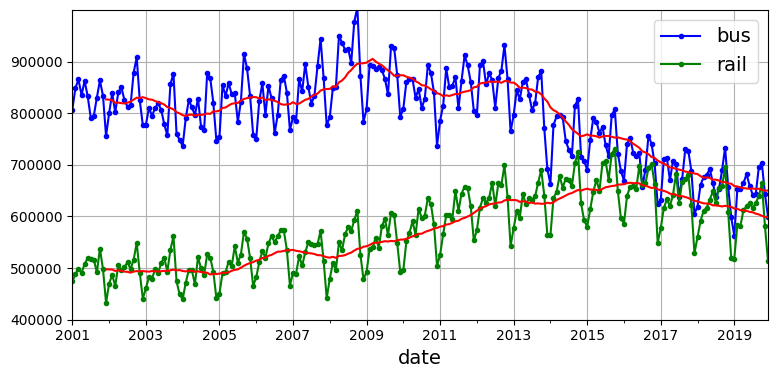

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))  # 8x4 ölçülü qrafik sahəsi yarat

df_monthly[period].plot(ax=ax, marker=".",color=['b','g'])  # Aylıq məlumatları nöqtə işarəsi ilə qrafikə çək

rolling_average_12_months.plot(ax=ax, grid=True, legend=False,color='r')  # 12 aylıq hərəkətli ortalamanı qrafikə əlavə et (tor xətləri ilə)

ax.set_ylim([400_000, 999_999])                                    # extra code – beautifies the plot
save_fig("long_term_ridership_plot")  # Qrafiki "long_term_ridership_plot" adı ilə yadda saxla
plt.show()                             # Qrafiki göstər

In [24]:
df_monthly.head(13)

,bus,rail
date,,
2001-01-31,807190.580645,474591.419355
2001-02-28,848889.000000,488188.178571
2001-03-31,865392.419355,498825.096774
2001-04-30,835126.366667,490444.533333
2001-05-31,862701.419355,507862.258065
2001-06-30,833149.033333,519549.900000
2001-07-31,791519.258065,516928.967742
2001-08-31,795070.580645,516604.387097
2001-09-30,830298.400000,491522.833333


In [25]:
df_monthly.diff(12)[period].head(13)  #  12 ay evvelki deyer ferqi

,bus,rail
date,,
2001-01-31,NaN,NaN
2001-02-28,NaN,NaN
2001-03-31,NaN,NaN
2001-04-30,NaN,NaN
2001-05-31,NaN,NaN
2001-06-30,NaN,NaN
2001-07-31,NaN,NaN
2001-08-31,NaN,NaN
2001-09-30,NaN,NaN


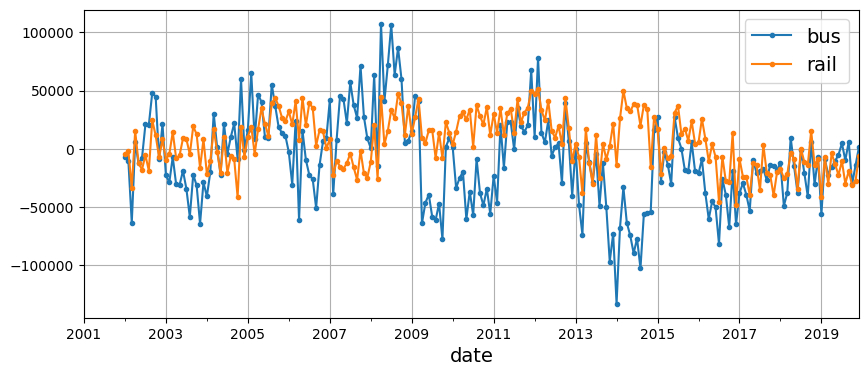

In [26]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(10, 4))

plt.show()

If running on Colab or Kaggle, install the statsmodels library:

### ARIMA 

In [27]:
from statsmodels.tsa.arima.model import ARIMA    # ARIMA modelini yükləyirik

origin, today = "2019-01-01", "2019-05-31"      # Təlim dövrünü təyin edirik: 2019-01-01 - 2019-05-31 arası

rail_series = df.loc[origin:today]['rail'].asfreq('D') 
# DataFrame-dən "rail" sütununu seçir, həmin tarix aralığını götürür.
# asfreq("D") - məlumatları günlük (Daily) formata çevirir , rail_series = günlük dəmiryolu sərnişin sayı (1 Yanvar - 31 May)

model = ARIMA(rail_series,  
              order=(1, 0, 0),
              seasonal_order=(0, 1, 1, 7))
# ARIMA modelini qururuq:
# order=(1,0,0) → qeyri-mövsümi hissə:
#   - p=1: 1 keçmiş dəyərə bax (AR)
#   - d=0: differencing yox
#   - q=0: MA yox
# seasonal_order=(0,1,1,7) → mövsümi hissə:
#   - P=0: mövsümi AR yox
#   - D=1: mövsümi differencing (1 dəfə)
#   - Q=1: mövsümi MA (1 keçmiş səhvə bax)
#   - s=7: həftəlik mövsüm (7 gün)


model = model.fit()
# Modeli məlumatlara uyğunlaşdırır (öyrədir)

y_pred = model.forecast()
# Növbəti gün üçün proqnoz verir (2019-06-01)

y_pred
# returns 427,758.6


2019-06-01    427758.62628
Freq: D, dtype: float64

In [28]:
y_pred[0]    # ARIMA forecast

C:\Users\USER\AppData\Local\Temp\ipykernel_28528\3165411883.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred[0]    # ARIMA forecast


427758.6262801082

In [29]:
df["rail"].loc["2019-06-01"]    # target value

379044

In [30]:
df["rail"].loc["2019-05-25"]  # naive forecast (value from one week earlier)

426932

**Warning**: Accessing Pandas `Series` by index directly is deprecated, so I replaced `model.forecast()[0]` with `model.forecast().iloc[0]`:

In [31]:
origin, start_date, end_date = '2019-01-01', '2019-03-01', '2019-05-31'


In [32]:
time_period =pd.date_range(start_date ,end_date)
time_period

DatetimeIndex(['2019-03-01', '2019-03-02', '2019-03-03', '2019-03-04',
               '2019-03-05', '2019-03-06', '2019-03-07', '2019-03-08',
               '2019-03-09', '2019-03-10', '2019-03-11', '2019-03-12',
               '2019-03-13', '2019-03-14', '2019-03-15', '2019-03-16',
               '2019-03-17', '2019-03-18', '2019-03-19', '2019-03-20',
               '2019-03-21', '2019-03-22', '2019-03-23', '2019-03-24',
               '2019-03-25', '2019-03-26', '2019-03-27', '2019-03-28',
               '2019-03-29', '2019-03-30', '2019-03-31', '2019-04-01',
               '2019-04-02', '2019-04-03', '2019-04-04', '2019-04-05',
               '2019-04-06', '2019-04-07', '2019-04-08', '2019-04-09',
               '2019-04-10', '2019-04-11', '2019-04-12', '2019-04-13',
               '2019-04-14', '2019-04-15', '2019-04-16', '2019-04-17',
               '2019-04-18', '2019-04-19', '2019-04-20', '2019-04-21',
               '2019-04-22', '2019-04-23', '2019-04-24', '2019-04-25',
      

In [33]:
time_period.shift(-1)  # bir gun geriden gelir

DatetimeIndex(['2019-02-28', '2019-03-01', '2019-03-02', '2019-03-03',
               '2019-03-04', '2019-03-05', '2019-03-06', '2019-03-07',
               '2019-03-08', '2019-03-09', '2019-03-10', '2019-03-11',
               '2019-03-12', '2019-03-13', '2019-03-14', '2019-03-15',
               '2019-03-16', '2019-03-17', '2019-03-18', '2019-03-19',
               '2019-03-20', '2019-03-21', '2019-03-22', '2019-03-23',
               '2019-03-24', '2019-03-25', '2019-03-26', '2019-03-27',
               '2019-03-28', '2019-03-29', '2019-03-30', '2019-03-31',
               '2019-04-01', '2019-04-02', '2019-04-03', '2019-04-04',
               '2019-04-05', '2019-04-06', '2019-04-07', '2019-04-08',
               '2019-04-09', '2019-04-10', '2019-04-11', '2019-04-12',
               '2019-04-13', '2019-04-14', '2019-04-15', '2019-04-16',
               '2019-04-17', '2019-04-18', '2019-04-19', '2019-04-20',
               '2019-04-21', '2019-04-22', '2019-04-23', '2019-04-24',
      

In [34]:
rail_series = df.loc[origin:end_date]['rail'].asfreq('D')
rail_series

date
2019-01-01    245852
2019-01-02    573542
2019-01-03    627781
2019-01-04    628514
2019-01-05    348257
               ...  
2019-05-27    256757
2019-05-28    694292
2019-05-29    717681
2019-05-30    735508
2019-05-31    738322
Freq: D, Name: rail, Length: 151, dtype: int64

In [35]:
# print(rail_series.head(5))
y_preds = []

for today in time_period.shift(-1):
   model = ARIMA(rail_series[origin:today],
                 order = (1,0,0),
                 seasonal_order = (0,1,1,7))
   
   model  = model.fit()
   y_pred = model.forecast().iloc[0]
   y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index = time_period)
print(y_preds)

2019-03-01    696955.515299
2019-03-02    342139.360984
2019-03-03    253320.415578
2019-03-04    633245.753022
2019-03-05    696723.448651
                  ...      
2019-05-27    736799.259383
2019-05-28    403824.542510
2019-05-29    721311.482966
2019-05-30    726614.005055
2019-05-31    699026.523604
Freq: D, Length: 92, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_28528\2632930558.py:6: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(y_preds, color="r", marker=".", label="SARIMA Forecasts")


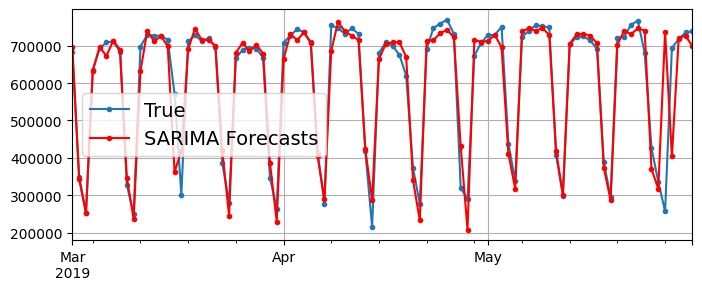

In [36]:
# extra code – displays the SARIMA forecasts
fig, ax = plt.subplots(figsize=(8, 3))
real = rail_series.loc[time_period]

real.plot(label="True", ax=ax, marker=".", grid=True)
ax.plot(y_preds, color="r", marker=".", label="SARIMA Forecasts")
plt.legend()
plt.show()

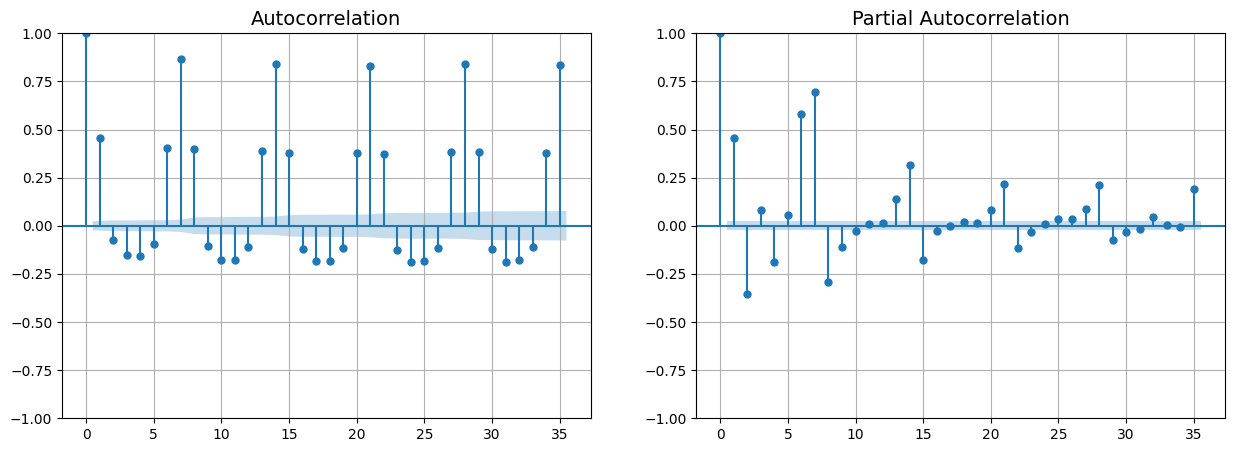

In [37]:
# extra code – shows how to plot the Autocorrelation Function (ACF) and the
#              Partial Autocorrelation Function (PACF)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

plot_acf(df[period]["rail"], ax=axs[0], lags=35)
axs[0].grid()

plot_pacf(df[period]["rail"], ax=axs[1], lags=35, method="ywm")
axs[1].grid()
plt.show()

In [38]:
import tensorflow as tf

my_series = [0,1,2,3,4,5]
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
                                            my_series,
                                            targets = my_series[3:],
                                            sequence_length=3,
                                            batch_size= 2
                                            )

list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]])>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4])>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]])>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5])>)]

In [39]:
for window_dataset in tf.data.Dataset.range(6).window(4, shift=1):
    for element in window_dataset:
        print(f"{element}", end=",")
    print()

0,1,2,3,
1,2,3,4,
2,3,4,5,
3,4,5,
4,5,
5,


In [40]:
dataset = tf.data.Dataset.range(6).window(4, shift=1, drop_remainder=True)
# 0-dan 5-ə qədər ədədlər yaradır
# window=4: Hər pəncərədə 4 element olacaq
# shift=1: Pəncərə hər dəfə 1 addım irəliləyir
# drop_remainder=True: Tam olmayan pəncərələri atır

# Pəncərə 1: [0, 1, 2, 3]  (bir dataset kimi)
# Pəncərə 2: [1, 2, 3, 4]  (bir dataset kimi)
# Pəncərə 3: [2, 3, 4, 5]  (bir dataset kimi)
# Pəncərə 4: [3, 4, 5]     (atıldı - 4 element deyil)
# Pəncərə 5: [4, 5]        (atıldı)
# Pəncərə 6: [5]           (atıldı)

#  İndi dataset dataset-lərdən ibarət dataset-dir!
#  3 pencere var , 4  eded saxlayir

dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))
# window_dataset → yuxarıdakı hər bir daxili dataset (məsələn [0,1,2,3] dataset-i)
# .batch(4) → həmin daxili dataset-dəki bütün elementləri götürüb tək tensor halına gətirir
# flat_map → bütün bu tensor-ları yan-yana düzərək tək dataset yaradır

for window_tensor in dataset:
    print(f"{window_tensor}")
# Hər tensor 4 elementdən ibarət
# 3 tensor var (çünki 3 tam pəncərə var idi)


[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


In [41]:
def to_windows(dataset, length):
    # dataset-i pəncərələrə böl: hər pəncərədə 'length' qədər element, 1 addım irəlilə
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    # nested dataset-i flat-ə çevir: hər pəncərəni tək tensor halına gətir
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

# 0-dan 5-ə qədər rəqəmlərdən ibarət dataset yarat və 4-lük pəncərələrə böl
dataset = to_windows(tf.data.Dataset.range(6), 4)
# Bu nöqtədə dataset = [ [0,1,2,3], 
#                        [1,2,3,4],
#                        [2,3,4,5] ] (tensorlar)

# Hər pəncərəni (input, target) cütlüyünə çevir:
# window[:-1] = pəncərənin sonuncu elementdən başqa hamısı (input)
# window[-1]  = pəncərənin sonuncu elementi (target)
dataset = dataset.map(lambda window: (window[:-1], window[-1]))

# Dataset-i batch-lərə böl (hər batch-də 2 nümunə) və siyahıya çevir
list(dataset.batch(2))

[(<tf.Tensor: shape=(2, 3), dtype=int64, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int64)>,
  <tf.Tensor: shape=(2,), dtype=int64, numpy=array([3, 4], dtype=int64)>),
 (<tf.Tensor: shape=(1, 3), dtype=int64, numpy=array([[2, 3, 4]], dtype=int64)>,
  <tf.Tensor: shape=(1,), dtype=int64, numpy=array([5], dtype=int64)>)]

Before we continue looking at the data, let's split the time series into three periods, for training, validation and testing. We won't look at the test data for now:

In [42]:
# Rail ridership (dəmiryolu sərnişin) məlumatları üzərində işləyirik
# Məqsəd: train/validation/test split etmək

# Ölçüləri 1 milyona bölürük (1e6 = 1,000,000)
# Bu, dəyərləri 0-1 aralığına endirir
# Niyə? Neural network-lər kiçik dəyərlərlə daha yaxşı işləyir (learning rate və weight initialization üçün uyğundur)

# TRAIN set (Təlim məlumatları): 2016-2018 arası (3 il)
# Model bu məlumatlarla öyrənəcək
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6

# VALIDATION set (Doğrulama məlumatları): 2019-01 - 2019-05 arası (5 ay)
# Modelin öyrəndiklərini yoxlamaq üçün (hyperparameter tənzimləmə)
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6

# TEST set (Test məlumatları): 2019-06 və sonrası
# Modelin son performansını ölçmək üçün (heç vaxt görünməyən məlumatlar)
rail_test = df["rail"]["2019-06":] / 1e6

# ⚠️ ƏHƏMİYYƏTLİ: Time series-də ZAMAN ÜZRƏ split tövsiyə olunur
# Yəni təsadüfi bölmək yox, tarix sırasına görə bölmək lazımdır
# Səbəb: Gələcək məlumatları keçmişi öyrədərkən istifadə edə bilmərik!

# ⚠️ XƏBƏRDARLIQ: Bəzən başqa üsullarla split etmək mümkündür
# Amma əgər məlumatlar bir-biri ilə əlaqəlidirsə (correlated)
# Test set-də süni yüksək nəticələr (optimistik) alına bilər!
# Bu, modelin əsl performansını olduğundan yaxşı göstərər

In [43]:
# seq_length = 56 -> son 8 həftənin (56 gün) məlumatları
# Hər input sequence 56 günlük məlumatdan ibarət olacaq
seq_length = 56

# TRAIN dataset yaradırıq
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),              # Train məlumatları (array formatında)
    targets=rail_train[seq_length:],    # Hər 56 günlük pəncərədən sonrakı dəyər (target)
    sequence_length=seq_length,         # Pəncərə uzunluğu: 56 gün
    batch_size=32,                      # Hər batch-də 32 nümunə
    shuffle=True,                        # Məlumatları qarışdır (IID assumption üçün)
    seed=42                              # Təkrarlana bilmək üçün random seed
)

# VALIDATION dataset yaradırıq
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),              # Validation məlumatları
    targets=rail_valid[seq_length:],    # Hər 56 günlük pəncərədən sonrakı dəyər
    sequence_length=seq_length,         # Pəncərə uzunluğu: 56 gün
    batch_size=32                       # Hər batch-də 32 nümunə
    # shuffle=False (default) - validation üçün qarışdırma yox
)

# Artıq regression model qurmaq və training başlamaq üçün DATA HAZIRDIR!

In [44]:
# 1️⃣ MODELİN QURULMASI
tf.random.set_seed(42)  # Təkrarlana bilən nəticələr üçün random seed sabitlənir

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[seq_length])  # seq_length = 56 gün
])
# Dense(1): 56 giriş (son 56 gün) → 1 çıxış (sabahkı gün)
# Formula: ŷ(t+1) = w₁·y(t) + w₂·y(t-1) + ... + w₅₆·y(t-55) + b

# 2️⃣ EARLY STOPPING (Overfitting-in qarşısını almaq üçün)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",        # Validation MAE-ni izlə
    patience=50,              # 50 epoch yaxşılaşma olmazsa dayan
    restore_best_weights=True # Ən yaxşı weight-ləri qaytar
)

# 3️⃣ OPTIMIZER (Gradient descent)
opt = tf.keras.optimizers.SGD(
    learning_rate=0.02,       # Addım ölçüsü
    momentum=0.9              # Əvvəlki gradient istiqamətini nəzərə al
)
# Momentum: gradient-in sürətini və istiqamətini sabitləşdirir

# 4️⃣ MODELİ KOMPİLYASİYA ET
model.compile(
    loss=tf.keras.losses.Huber(),  # Kiçik səhvlər MSE, böyük səhvlər MAE kimi
    optimizer=opt,                  # SGD optimizer
    metrics=["mae"]                  # Performance metriki: Mean Absolute Error
)
# Huber loss: Outlier-lərə qarşı davamlı

# 5️⃣ MODELİ TRAİN ET
history = model.fit(
    train_ds,                 # Training dataset (56 günlük pəncərələr)
    validation_data=valid_ds, # Validation dataset
    epochs=500,               # Maksimum 500 epoch
    callbacks=[early_stopping_cb]  # Early stopping aktiv
)
# Hər epoch: model train-də öyrənir, validation-da yoxlanılır


Epoch 1/500


33/33 [==============================] - 1s 9ms/step - loss: 0.1212 - mae: 0.3760 - val_loss: 0.0138 - val_mae: 0.1300
Epoch 2/500
33/33 [==============================] - 0s 4ms/step - loss: 0.0121 - mae: 0.1136 - val_loss: 0.0070 - val_mae: 0.0838
Epoch 3/500
33/33 [==============================] - 0s 4ms/step - loss: 0.0087 - mae: 0.0945 - val_loss: 0.0066 - val_mae: 0.0823
Epoch 4/500
33/33 [==============================] - 0s 4ms/step - loss: 0.0075 - mae: 0.0884 - val_loss: 0.0061 - val_mae: 0.0824
Epoch 5/500
33/33 [==============================] - 0s 4ms/step - loss: 0.0067 - mae: 0.0830 - val_loss: 0.0055 - val_mae: 0.0761
Epoch 6/500
33/33 [==============================] - 0s 4ms/step - loss: 0.0056 - mae: 0.0735 - val_loss: 0.0057 - val_mae: 0.0781
Epoch 7/500
33/33 [==============================] - 0s 4ms/step - loss: 0.0056 - mae: 0.0756 - val_loss: 0.0054 - val_mae: 0.0754
Epoch 8/500
33/33 [==============================] - 0s 4ms/step - loss: 0.0051 

In [45]:
# extra code – evaluates the model
valid_loss, valid_mae = model.evaluate(valid_ds)
valid_mae * 1e6

3/3 [==============================] - 0s 0s/step - loss: 0.0022 - mae: 0.0374


37380.54633140564

## Using a Simple RNN

In [46]:
# extra code – defines a utility function we'll reuse several time

def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
                                                        monitor="val_mae",
                                                        patience=50,
                                                        restore_best_weights=True
                                                        )
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate,
                                  momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(),
                  optimizer=opt,
                  metrics=["mae"])

    history = model.fit(train_set,
                        validation_data=valid_set, 
                        epochs=epochs,
                        callbacks=[early_stopping_cb],
                        verbose = 0)
    
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6

In [47]:
import tensorflow as tf

# Tək neyronlu sadə RNN modeli
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

model.summary()

# 📌 İZAH:
# SimpleRNN(1) → 1 neyronlu (unit) RNN layer-i

# input_shape=[None, 1] parametrinin mənası:
#   - None:   ZAMAN ADDIMLARI (time steps) - istənilən uzunluqda ola bilər
#            (məsələn: 56 gün, 100 gün və ya dəyişən uzunluq)
#   - 1:      ÖLÇÜ (dimensionality) - hər zaman addımında tək dəyər var
#            (univariate time series - tək dəyişən)



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 1)                 3         
                                                                 
Total params: 3 (12.00 Byte)
Trainable params: 3 (12.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [48]:
# fit_and_evaluate(model, train_ds, valid_ds, learning_rate=0.02)

In [49]:
tf.random.set_seed(42)

univar_model = tf.keras.Sequential([
                                    tf.keras.layers.SimpleRNN(32 , input_shape=[None , 1]),
                                    tf.keras.layers.Dense( 1 )
                                    ])

In [50]:

tf.random.set_seed(42)  # extra code – ensures reproducibility
# Təkmilləşdirilmiş RNN modeli
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1) 
])

univar_model.summary()
univar_model.save("my_rnn_model.h5")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 32)                1088      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1121 (4.38 KB)
Trainable params: 1121 (4.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


c:\Users\USER\envs\mydl_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [51]:


# fit_and_evaluate(univar_model, train_ds, valid_ds, learning_rate=0.05)

## Deep RNNs

In [52]:
import tensorflow as tf

# Hər dəfə kodu işə salanda eyni təsadüfi rəqəmlərin yaranmasını təmin edir.
# Bu, modelin nəticələrinin "təkrar istehsal edilə bilən" (reproducibility) olması üçün vacibdir.
tf.random.set_seed(42) 

# Ardıcıl laylardan ibarət olan model strukturunu yaradır.
deep_model = tf.keras.Sequential([
                                    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
                                    tf.keras.layers.SimpleRNN(32, return_sequences=True),
                                    tf.keras.layers.SimpleRNN(32),
                                    tf.keras.layers.Dense(1)
                                ])

deep_model.save("deeper_rnn_model.h5")

In [53]:

# fit_and_evaluate(deep_model, train_ds, valid_ds, learning_rate=0.01)

## Multivariate time series

**Warning**: in recent Pandas versions, `get_dummies()` returns booleans instead of floats, so I added `dtype=float` to ensure we get floats.

In [54]:
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


In [55]:
df_mulvar = df[["bus", "rail"]] / 1e6  #  1000000  boluruk
df_mulvar

,bus,rail
date,,
2001-01-01,0.297192,0.126455
2001-01-02,0.780827,0.501952
2001-01-03,0.824923,0.536432
2001-01-04,0.870021,0.550011
2001-01-05,0.890426,0.557917
...,...,...
2021-11-26,0.257700,0.189694
2021-11-27,0.237839,0.187065
2021-11-28,0.184817,0.147830


In [56]:
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


In [57]:
df_mulvar["next_day_type"] = df["day_type"].shift(-1)   #  bir evvelki 
df_mulvar

,bus,rail,next_day_type
date,,,
2001-01-01,0.297192,0.126455,W
2001-01-02,0.780827,0.501952,W
2001-01-03,0.824923,0.536432,W
2001-01-04,0.870021,0.550011,W
2001-01-05,0.890426,0.557917,A
...,...,...,...
2021-11-26,0.257700,0.189694,A
2021-11-27,0.237839,0.187065,U
2021-11-28,0.184817,0.147830,W


In [58]:
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)
df_mulvar

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.297192,0.126455,0.0,0.0,1.0
2001-01-02,0.780827,0.501952,0.0,0.0,1.0
2001-01-03,0.824923,0.536432,0.0,0.0,1.0
2001-01-04,0.870021,0.550011,0.0,0.0,1.0
2001-01-05,0.890426,0.557917,1.0,0.0,0.0
...,...,...,...,...,...
2021-11-26,0.257700,0.189694,1.0,0.0,0.0
2021-11-27,0.237839,0.187065,0.0,1.0,0.0
2021-11-28,0.184817,0.147830,0.0,0.0,1.0


In [59]:

mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test  = df_mulvar["2019-06":]

In [60]:
mulvar_train

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2016-01-01,0.303321,0.319835,1.0,0.0,0.0
2016-01-02,0.448859,0.365509,0.0,1.0,0.0
2016-01-03,0.340540,0.287661,0.0,0.0,1.0
2016-01-04,0.829429,0.703185,0.0,0.0,1.0
2016-01-05,0.846789,0.727716,0.0,0.0,1.0
...,...,...,...,...,...
2018-12-27,0.509948,0.453029,0.0,0.0,1.0
2018-12-28,0.577497,0.493961,1.0,0.0,0.0
2018-12-29,0.394088,0.307105,0.0,1.0,0.0


In [61]:
mulvar_train.to_numpy()

array([[0.303321, 0.319835, 1.      , 0.      , 0.      ],
       [0.448859, 0.365509, 0.      , 1.      , 0.      ],
       [0.34054 , 0.287661, 0.      , 0.      , 1.      ],
       ...,
       [0.394088, 0.307105, 0.      , 1.      , 0.      ],
       [0.31455 , 0.26531 , 0.      , 0.      , 1.      ],
       [0.463165, 0.386058, 0.      , 1.      , 0.      ]])

In [62]:
mulvar_train['rail']

date
2016-01-01    0.319835
2016-01-02    0.365509
2016-01-03    0.287661
2016-01-04    0.703185
2016-01-05    0.727716
                ...   
2018-12-27    0.453029
2018-12-28    0.493961
2018-12-29    0.307105
2018-12-30    0.265310
2018-12-31    0.386058
Name: rail, Length: 1096, dtype: float64

In [63]:
mulvar_train['rail'][seq_length:] #  56 dan sonra 

date
2016-02-26    0.749991
2016-02-27    0.455421
2016-02-28    0.323758
2016-02-29    0.742972
2016-03-01    0.741922
                ...   
2018-12-27    0.453029
2018-12-28    0.493961
2018-12-29    0.307105
2018-12-30    0.265310
2018-12-31    0.386058
Name: rail, Length: 1040, dtype: float64

In [64]:
tf.random.set_seed(42)

train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),  #  yanlniz reqemler matrisi
    targets = mulvar_train['rail'][seq_length:], #  56 dan sonra 
    # Nümunə: Giriş: indeks 0-55 (56 zaman addımı) → Hədəf: indeks 56 (rail dəyəri)
    sequence_length = seq_length, #  56 liq 
    batch_size = 32,
    shuffle = True,
    seed = 42,
)

valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets = mulvar_valid['rail'][seq_length:],
    sequence_length = seq_length,
    batch_size = 32,
    seed = 42
)


In [65]:
# Hər dəfə eyni çəkilərin (weights) yaranmasını təmin edir ki, nəticələr stabil qalsın.
tf.random.set_seed(42)  

# Ardıcıl laylardan ibarət çoxşaxəli proqnoz modelini yaradır.
mulvar_model = tf.keras.Sequential([
                    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]), #  5,1 li  vektor girir her bloka , 32 -neyron var ,  ceki sayi  
                    tf.keras.layers.Dense(1)
                                ])
mulvar_model.save("multivariate_rnn_model.h5")


c:\Users\USER\envs\mydl_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [66]:
# extra code – compiles, fits, and evaluates the model, like earlier

# fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds,  learning_rate=0.05)

In [67]:
# extra code – build and train a multitask RNN that forecasts both bus and rail

tf.random.set_seed(42)

seq_length = 56
train_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=mulvar_train[["bus", "rail"]][seq_length:],  # 2 targets per day
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid[["bus", "rail"]][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

tf.random.set_seed(42)
multask_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(2)
])

# fit_and_evaluate(multask_model, train_multask_ds, valid_multask_ds,
#                  learning_rate=0.02)

In [68]:
mulvar_valid

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2019-01-01,0.248879,0.245852,0.0,0.0,1.0
2019-01-02,0.591006,0.573542,0.0,0.0,1.0
2019-01-03,0.664442,0.627781,0.0,0.0,1.0
2019-01-04,0.668812,0.628514,1.0,0.0,0.0
2019-01-05,0.444434,0.348257,0.0,1.0,0.0
...,...,...,...,...,...
2019-05-27,0.298987,0.256757,0.0,0.0,1.0
2019-05-28,0.769069,0.694292,0.0,0.0,1.0
2019-05-29,0.791059,0.717681,0.0,0.0,1.0


In [69]:
# extra code – evaluates the naive forecasts for bus
bus_naive = mulvar_valid["bus"].shift(7)[seq_length:]  #  7 gun qarsiya oturur ve 56 gun sonrani  secir 

bus_target = mulvar_valid["bus"][seq_length:]      #  56  gun sonani secir
 
(bus_target - bus_naive).abs().mean() * 1e6          # 56 ci gunden baslaayraq ,  



43441.63157894738

In [70]:
valid_multask_ds

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 5), dtype=tf.float64, name=None), TensorSpec(shape=(None, 2), dtype=tf.float64, name=None))>

In [71]:
# extra code – evaluates the multitask RNN's forecasts both bus and rail
Y_preds_valid = multask_model.predict(valid_multask_ds)

for idx, name in enumerate(["bus", "rail"]):
    print(idx ,  name )
    mae = 1e6 * tf.keras.metrics.MeanAbsoluteError()(
        mulvar_valid[name][seq_length:], Y_preds_valid[:, idx])
    print(name, int(mae))

3/3 [==============================] - 0s 8ms/step
0 bus
bus 1245687
1 rail
rail 650966


## Forecasting Several Steps Ahead

In [72]:
import numpy as np

In [73]:
X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]
X.shape

(1, 56, 1)

In [74]:
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X,verbose=0)
    print(y_pred_one.shape)
    print(X.shape)
    print(y_pred_one.reshape(1, 1, 1))
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

(1, 1)
(1, 56, 1)
[[[-0.00432324]]]
(1, 1)
(1, 57, 1)
[[[-0.4169065]]]
(1, 1)
(1, 58, 1)
[[[-0.32708886]]]
(1, 1)
(1, 59, 1)
[[[-0.02284777]]]
(1, 1)
(1, 60, 1)
[[[0.18709752]]]
(1, 1)
(1, 61, 1)
[[[0.30212042]]]
(1, 1)
(1, 62, 1)
[[[0.14091924]]]
(1, 1)
(1, 63, 1)
[[[-0.07791028]]]
(1, 1)
(1, 64, 1)
[[[0.13248469]]]
(1, 1)
(1, 65, 1)
[[[0.467229]]]
(1, 1)
(1, 66, 1)
[[[0.18112892]]]
(1, 1)
(1, 67, 1)
[[[-0.3288998]]]
(1, 1)
(1, 68, 1)
[[[-0.4018164]]]
(1, 1)
(1, 69, 1)
[[[-0.05708319]]]


In [75]:
X[0, -14:, 0]

array([-0.00432324, -0.41690651, -0.32708886, -0.02284777,  0.18709752,
        0.30212042,  0.14091924, -0.07791028,  0.13248469,  0.46722901,
        0.18112892, -0.3288998 , -0.4018164 , -0.05708319])

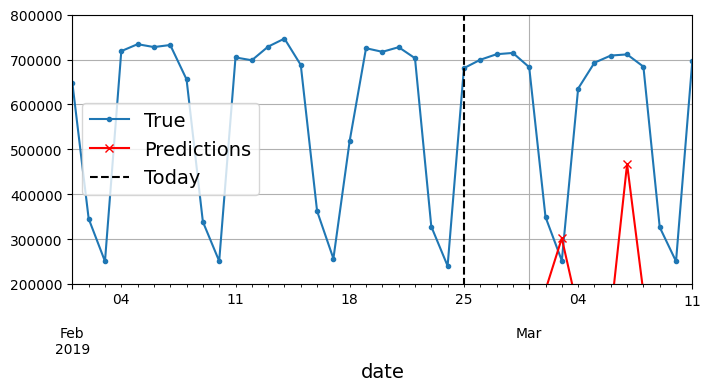

In [76]:
# extra code – generates and saves Figure 15–11

# The forecasts start on 2019-02-26, as it is the 57th day of 2019, and they end
# on 2019-03-11. That's 14 days in total.
Y_pred = pd.Series(X[0, -14:, 0],index=pd.date_range("2019-02-26", "2019-03-11"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-02-01":"2019-03-11"].plot( label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(label="Predictions", grid=True, marker="x", color="r", ax=ax)

ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])

plt.legend(loc="center left")
# save_fig("forecast_ahead_plot")
plt.show()

Now let's create an RNN that predicts all 14 next values at once:

In [77]:
# Hər dəfə eyni nəticələrin alınmasını təmin edir.
tf.random.set_seed(42)  

# 1. Parçalama Funksiyası: Giriş (X) və Hədəf (y) məlumatlarını bir-birindən ayırır.
def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    # Giriş (X): Pəncərənin son 14 günündən əvvəlki bütün hissə (seq_length qədər gün).
    # Hədəf (y): Pəncərənin son 14 günü və yalnız "rail" (target_col=1) sütunu.
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

# 2. Dataset Yaradılması: Pəncərənin ümumi uzunluğu (seq_length + 14) olaraq təyin edilir.
ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=None, # targets funksiyanın daxilində (.map vasitəsilə) ayrılacaq.
    sequence_length=seq_length + 14, 
    batch_size=32,
    shuffle=True,
    seed=42
).map(split_inputs_and_targets) # .map() funksiyanı hər batch üçün tətbiq edir.

# 3. Validasiya Dataseti: Eyni məntiqlə 14 günlük hədəflər yaradılır.
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32
).map(split_inputs_and_targets)

In [78]:
# Təcrübənin hər dəfə eyni nəticəni verməsi üçün təsadüfi ədədlər generatorunu sabitləyir.
tf.random.set_seed(42)  

# Çox-addımlı (Multi-step) proqnoz üçün ardıcıl model yaradır.
ahead_model = tf.keras.Sequential([
    
    # Rekurrent lay:
    # 32: Modelin daxili yaddaş tutumu (units).
    # [None, 5]: İstənilən uzunluqlu ardıcıllığı qəbul edir, hər addımda 5 fərqli məlumat (bus, rail, etc.) oxuyur.
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    
    # Çıxış (Dense) layı:
    # 14: Bu, modelin eyni anda növbəti 14 günün (məsələn, qatar sərnişin sayının) 
    # proqnozunu bir vektor kimi çıxarmasını təmin edir.
    tf.keras.layers.Dense(14)
])

In [79]:
# extra code – compiles, fits, and evaluates the model, like earlier
# fit_and_evaluate(ahead_model, ahead_train_ds, ahead_valid_ds, learning_rate=0.02)

3/3 [==============================] - 0s 5ms/step - loss: 0.0014 - mae: 0.0357


35651.400685310364

In [80]:
# 1. Girişin hazırlanması: Validasiya datasından ilk 'seq_length' qədər hissəni seçir.
# [np.newaxis, :seq_length]: Datanı [Batch, Time, Features] formatına (məs: [1, 56, 5]) salır.
# Burada 56 günün hər biri üçün 5 fərqli məlumat (bus, rail, 3 day type) modelə daxil olur.
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]

# 2. Proqnozun alınması: Model bütün 56 günlük tarixçəyə birbaşa baxır.
# Y_pred: Modelin çıxışı [1, 14] ölçüsündə olur, yəni növbəti 14 günün "rail" (qatar) sərnişin sayı.
# Bu üsul "for" döngüsü ilə edilən təxminlərdən daha sürətli və stabil nəticə verir.
Y_pred = ahead_model.predict(X)

1/1 [==============================] - 0s 162ms/step


--------------------------

Now let's create an RNN that predicts the next 14 steps at each time step. That is, instead of just forecasting time steps 56 to 69 based on time steps 0 to 55, it will forecast time steps 1 to 14 at time step 0, then time steps 2 to 15 at time step 1, and so on, and finally it will forecast time steps 56 to 69 at the last time step. Notice that the model is causal: when it makes predictions at any time step, it can only see past time steps.

To prepare the datasets, we can use `to_windows()` twice, to get sequences of consecutive windows, like this:

In [81]:
# 1. 0-dan 6-ya qədər rəqəmlər ardıcıllığı yaradır.
my_series = tf.data.Dataset.range(7)   # [0,1,2,3,4,5,6]

# 2. Öncə 3-lük pəncərələr yaradır, sonra həmin pəncərələrdən 4-lük qruplar düzəldir.
# Bu, "pəncərələrin pəncərəsi" (dataset of datasets) strukturunu formalaşdırır. 
a = to_windows(my_series, 3)
list(a)

[<tf.Tensor: shape=(3,), dtype=int64, numpy=array([0, 1, 2], dtype=int64)>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([1, 2, 3], dtype=int64)>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([2, 3, 4], dtype=int64)>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([3, 4, 5], dtype=int64)>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([4, 5, 6], dtype=int64)>]

In [82]:
dataset = to_windows(a, 4) 
list(dataset)

[<tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]], dtype=int64)>,
 <tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]], dtype=int64)>]

Then we can split these elements into the desired inputs and targets:

In [83]:
dataset = dataset.map(lambda S: (S[:, 0], S[:, 1:]))
# her iki tensoru  goturur , ilk birinici  0-ci  indexi  secir,
# S[:, 0]  , ilk birinici  0-ci  indexi  secir
# S[:, 1:]  1,2 ci sutunlari secir 
list(dataset)

[(<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 1, 2, 3], dtype=int64)>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[1, 2],
         [2, 3],
         [3, 4],
         [4, 5]], dtype=int64)>),
 (<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4], dtype=int64)>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[2, 3],
         [3, 4],
         [4, 5],
         [5, 6]], dtype=int64)>)]

Let's wrap this idea into a utility function. It will also take care of shuffling (optional) and batching:

In [84]:
mulvar_train

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2016-01-01,0.303321,0.319835,1.0,0.0,0.0
2016-01-02,0.448859,0.365509,0.0,1.0,0.0
2016-01-03,0.340540,0.287661,0.0,0.0,1.0
2016-01-04,0.829429,0.703185,0.0,0.0,1.0
2016-01-05,0.846789,0.727716,0.0,0.0,1.0
...,...,...,...,...,...
2018-12-27,0.509948,0.453029,0.0,0.0,1.0
2018-12-28,0.577497,0.493961,1.0,0.0,0.0
2018-12-29,0.394088,0.307105,0.0,1.0,0.0


In [85]:
def to_seq2seq_dataset(series, 
                       seq_length=56, 
                       ahead=14, 
                       target_col=1,
                       batch_size=32, 
                       shuffle=False, 
                       seed=None):
    
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1) # (15, 5)
    # ahead=14 olduğu üçün: 15 günlük pəncərələr

# 56 windows -li qruplari yaardir , 0 - X, qalanlari - y  edir .
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, target_col]))
# X: (56, 5)  - 56 gün, hər gün üçün 5 feature
# y: (56, 14) - 56 gün, hər gün üçün 14 günlük temperatur


    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed) # 256 liq melmat goturub shuffle edir 
    
    return ds.batch(batch_size) #  32 lik  ruplara bolur melumati
# X=(32,56,5), y=(32,56,14)


seq2seq_train = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42)
seq2seq_valid = to_seq2seq_dataset(mulvar_valid)

In [86]:
# Təcrübənin təkrar oluna bilən (reproducible) olması üçün təsadüfi ədədlər generatorunu sabitləyir.
tf.random.set_seed(42)  

# Seq-to-Seq (ardıcıllıqdan-ardıcıllığa) modelini yaradır.
seq2seq_model = tf.keras.Sequential([
    
    # Rekurrent lay:
    # 32: Modelin yaddaş hüceyrələrinin (units) sayı.
    # return_sequences=True: Bu modelin yalnız sonda deyil, hər bir zaman addımı (t=1, t=2, ...) üçün 
    # bir çıxış (yaddaş vektoru) qaytarmasını təmin edir.
    # input_shape=[None, 5]: İstənilən uzunluqlu ardıcıllığı və 5 fərqli məlumat növünü qəbul edir.
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 5]),
    
    # Sıx (Dense) lay:
    # Bu lay RNN-dən gələn hər bir zaman addımına aid 32 ölçülü vektoru 14 ölçülü proqnoz vektoruna çevirir.
    # Nəticədə model hər addımda (məsələn, 56 günün hər birində) növbəti 14 günü təxmin edir.
    tf.keras.layers.Dense(14)
])

In [87]:
# fit_and_evaluate(seq2seq_model, seq2seq_train, seq2seq_valid,learning_rate=0.1)

In [88]:
# 1. Girişin hazırlanması: Validasiya datasından ilk 'seq_length' (məsələn, 56 gün) qədər hissəni seçir.
# [np.newaxis, :seq_length] -> Datanı [1, 56, 5] ölçüsünə (Batch, Time, Features) gətirir.
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]

# 2. Proqnozun alınması və filtrasiya:
# seq2seq_model.predict(X) -> Bütün zaman addımları üçün [1, 56, 14] ölçülü matris qaytarır.
# [0, -1] -> Bizə yalnız ən sonuncu zaman addımındakı (yəni 56-cı gündə durarkən verilən) 
# növbəti 14 günlük proqnoz lazımdır. Nəticə [14] ölçülü bir vektor olur.
y_pred_14 = seq2seq_model.predict(X)[0,-1]
print(y_pred_14)

1/1 [==============================] - 0s 168ms/step
[ 0.01199656  0.01470554  0.14282548  0.867795   -0.07753646 -0.87153006
 -0.8682678   0.35295144 -0.4147455  -0.89690393 -0.8199999  -0.84806967
 -0.4792078  -0.88012826]


In [89]:
Y_pred_valid = seq2seq_model.predict(seq2seq_valid)
for ahead in range(14):
    preds = pd.Series(Y_pred_valid[:-1, -1, ahead],
                      index=mulvar_valid.index[56 + ahead : -14 + ahead])
    mae = (preds - mulvar_valid["rail"]).abs().mean() * 1e6
    print(f"MAE for +{ahead + 1}: {mae:,.0f}")

3/3 [==============================] - 0s 12ms/step
MAE for +1: 1,281,104
MAE for +2: 356,891
MAE for +3: 442,005
MAE for +4: 252,088
MAE for +5: 755,708
MAE for +6: 1,575,513
MAE for +7: 1,479,961
MAE for +8: 626,636
MAE for +9: 670,180
MAE for +10: 1,787,765
MAE for +11: 1,300,715
MAE for +12: 1,119,321
MAE for +13: 1,107,001
MAE for +14: 1,279,858


# Deep RNNs with Layer Norm

In [90]:
# 1. Xüsusi RNN Hüceyrəsi: tf.keras.layers.Layer-dən miras alaraq yeni bir lay yaradır.
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        # RNN hüceyrəsi üçün vacib olan yaddaş (state) və çıxış ölçülərini təyin edir.
        self.state_size = units
        self.output_size = units
        
        # 2. Daxili strukturlar:
        # activation=None: Çünki aktivasiyanı normallaşdırmadan SONRA tətbiq edəcəyik.
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units, activation=None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    # 3. Hesablama məntiqi (Forward Pass):
    def call(self, inputs, states):
        # Öncə standart RNN hesablamasını (W*x + U*h + b) aparır.
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        
        # 4. Normallaşdırma və Aktivasiya:
        # Çıxışı öncə LayerNorm-dan keçirir, sonra tanh (və ya başqa) aktivasiyasını tətbiq edir.
        norm_outputs = self.activation(self.layer_norm(outputs))
        
        # RNN-də çıxış həm də növbəti addımın "yaddaşı" (state) olduğu üçün hər ikisini qaytarır.
        return norm_outputs, [norm_outputs]

In [ ]:
# Təcrübənin təkrar oluna bilən (reproducible) olması üçün təsadüfi ədədlər generatorunu sabitləyir.
tf.random.set_seed(42)  

# Xüsusi LN hüceyrəsi ilə təchiz olunmuş Seq-to-Seq modelini yaradır.
custom_ln_model = tf.keras.Sequential([
    # Rekurrent lay (Custom):
    # tf.keras.layers.RNN: Bu lay ümumi bir qabıqdır, daxilinə istənilən RNN hüceyrəsini (LNSimpleRNNCell) qoya bilərsən.
    # 32: Hüceyrənin daxili neyron (units) sayı.
    # return_sequences=True: Hər zaman addımı üçün 14 günlük proqnoz çıxarmaq (Seq-to-Seq) üçün vacibdir.
    # input_shape=[None, 5]: 5 fərqli giriş sütunu (bus, rail və gün növləri) üçün.
    tf.keras.layers.RNN(LNSimpleRNNCell(32), return_sequences=True,
                        input_shape=[None, 5]),
    
    # Çıxış (Dense) layı:
    # RNN-dən gələn normallaşdırılmış çıxışları növbəti 14 günün sərnişin sayına (vektoruna) çevirir.
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [ ]:
fit_and_evaluate(custom_ln_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

# Extra Material – Creating a Custom RNN Class

The RNN class is not magical. In fact, it's not too hard to implement your own RNN class:

In [ ]:
class MyRNN(tf.keras.layers.Layer):
    def __init__(self, cell, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.cell = cell
        self.return_sequences = return_sequences

    def get_initial_state(self, inputs):
        try:
            return self.cell.get_initial_state(inputs)
        except AttributeError:
            # fallback to zeros if self.cell has no get_initial_state() method
            batch_size = tf.shape(inputs)[0]
            return [tf.zeros([batch_size, self.cell.state_size],
                             dtype=inputs.dtype)]

    @tf.function
    def call(self, inputs):
        states = self.get_initial_state(inputs)
        shape = tf.shape(inputs)
        batch_size = shape[0]
        n_steps = shape[1]
        sequences = tf.TensorArray(
            inputs.dtype, size=(n_steps if self.return_sequences else 0))
        outputs = tf.zeros(shape=[batch_size, self.cell.output_size],
                           dtype=inputs.dtype)
        for step in tf.range(n_steps):
            outputs, states = self.cell(inputs[:, step], states)
            if self.return_sequences:
                sequences = sequences.write(step, outputs)

        if self.return_sequences:
            # stack the outputs into an array of shape
            # [time steps, batch size, dims], then transpose it to shape
            # [batch size, time steps, dims]
            return tf.transpose(sequences.stack(), [1, 0, 2])
        else:
            return outputs

Note that `@tf.function` requires the `outputs` variable to be created before the `for` loop, which is why we initialize its value to a zero tensor, even though we don't use that value at all. Once the function is converted to a graph, this unused value will be pruned from the graph, so it doesn't impact performance. Similarly, `@tf.function` requires the `sequences` variable to be created before the `if` statement where it is used, even if `self.return_sequences` is `False`, so we create a `TensorArray` of size 0 in this case.

In [ ]:
tf.random.set_seed(42)

custom_model = tf.keras.Sequential([
    MyRNN(LNSimpleRNNCell(32), return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [ ]:
fit_and_evaluate(custom_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

# LSTMs

In [ ]:
# Təcrübənin hər dəfə eyni nəticəni verməsi üçün təsadüfi ədədlər generatorunu sabitləyir.
tf.random.set_seed(42)  

# Ardıcıl laylardan ibarət LSTM modelini müəyyən edir.
lstm_model = tf.keras.models.Sequential([
    
    # LSTM layı:
    # 32: Modelin daxili "yaddaş hüceyrələrinin" (units) sayı.
    # return_sequences=True: Hər zaman addımı (məs: 56 günün hər biri) üçün çıxış qaytarır.
    # input_shape=[None, 5]: İstənilən uzunluqlu ardıcıllığı və 5 fərqli giriş sütununu qəbul edir.
    tf.keras.layers.LSTM(32, return_sequences=True, input_shape=[None, 5]),
    
    # Çıxış (Dense) layı:
    # LSTM-dən gələn hər bir addım üçün növbəti 14 günlük sərnişin sayını (vektor) təxmin edir.
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [ ]:
fit_and_evaluate(lstm_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

# GRUs

In [ ]:
# Təcrübənin hər dəfə eyni nəticəni verməsi üçün təsadüfi ədədlər generatorunu sabitləyir.
tf.random.set_seed(42)  

# Ardıcıl laylardan ibarət GRU modelini müəyyən edir.
gru_model = tf.keras.Sequential([
    
    # GRU layı:
    # 32: Modelin daxili yaddaş vahidlərinin (units) sayı.
    # return_sequences=True: Hər zaman addımı (məs: 56 günün hər biri) üçün çıxış qaytarır.
    # input_shape=[None, 5]: İstənilən uzunluqlu ardıcıllığı və 5 giriş xüsusiyyətini qəbul edir.
    tf.keras.layers.GRU(32, return_sequences=True, input_shape=[None, 5]),
    
    # Çıxış (Dense) layı:
    # GRU-dan gələn hər bir addım üçün növbəti 14 günlük sərnişin sayını (vektor) təxmin edir.
    tf.keras.layers.Dense(14)
])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [ ]:
fit_and_evaluate(gru_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

## Using One-Dimensional Convolutional Layers to Process Sequences

```
  |-----0-----|      |-----3----|      |--... |-------52------|
         |-----1----|      |-----4----|   ... |       |-------53------|
               |-----2----|     |------5--...-51------|       |-------54------|
X:  0  1  2  3  4  5  6  7  8  9 10 11 12 ...  104 105 106 107 108 109 110 111
Y:      from 4     6     8    10    12    ...      106     108     110     112
         to 17    19    21    23    25    ...      119     121     123     125
```

In [ ]:
# Təcrübənin təkrar oluna bilən (reproducible) olması üçün təsadüfi ədədlər generatorunu sabitləyir.
tf.random.set_seed(42)  

# Konvolusiya və GRU laylarından ibarət hibrid model yaradır.
conv_rnn_model = tf.keras.Sequential([
    # 1D Konvolusiya: 32 filtr vasitəsilə 4 günlük pəncərələrlə (kernel_size=4) datanı skan edir.
    # strides=2: Hər iki addımdan bir tullandığı üçün zaman ardıcıllığını yarıbayarı qısaldır.
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2,
                           activation="relu", input_shape=[None, 5]),
    
    # GRU layı: Konvolusiyadan gələn sıxılmış (abstract) xüsusiyyətlər üzərində zaman asılılığını öyrənir.
    tf.keras.layers.GRU(32, return_sequences=True),
    
    # Çıxış layı: Hər zaman addımı üçün növbəti 14 günlük proqnoz vektorunu çıxarır.
    tf.keras.layers.Dense(14)
])

# Daha uzun pəncərə (112 gün) hazırlayır ki, konvolusiya datanı sıxanda kifayət qədər məlumat qalsın.
longer_train = to_seq2seq_dataset(mulvar_train, seq_length=112, shuffle=True, seed=42)
longer_valid = to_seq2seq_dataset(mulvar_valid, seq_length=112)

# Hədəf (Y) datanı modelin çıxışına uyğunlaşdırır:
# strides=2 olduğu üçün model hər addımı deyil, hər 2 addımdan birini təxmin edir.
# Y[:, 3::2] -> İlk 3 günü atlayır (kernel-in təsirindən) və hər ikinci günü hədəf kimi götürür.
downsampled_train = longer_train.map(lambda X, Y: (X, Y[:, 3::2]))
downsampled_valid = longer_valid.map(lambda X, Y: (X, Y[:, 3::2]))

Just training for 5 epochs to show that it works (you can increase this if you want):

In [ ]:
fit_and_evaluate(conv_rnn_model, downsampled_train, downsampled_valid,
                 learning_rate=0.1, epochs=5)

## WaveNet

```
 ⋮
C2  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\...
   \  /  \  /  \  /  \  /  \  /  \  /  \     
     /    \      /    \      /    \          
C1  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\  /\ /...\
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 111
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 112
 /14 15 16 17 18 19 20 21 22  23 24 25 26 ... 125
```

In [ ]:
# Təcrübənin təkrar oluna bilən (reproducible) olması üçün təsadüfi ədədlər generatorunu sabitləyir.
tf.random.set_seed(42)  

# WaveNet tipli ardıcıl model yaradır.
wavenet_model = tf.keras.Sequential()

# Giriş layı: İstənilən uzunluqlu (None) və 5 fərqli xüsusiyyətli (features) datanı qəbul edir.
wavenet_model.add(tf.keras.layers.InputLayer(input_shape=[None, 5]))

# Dilated Convolution Döngüsü: (1, 2, 4, 8) * 2 ardıcıllığı ilə 8 ədəd lay əlavə edir.
# dilation_rate=rate: Neyronların arasını açaraq modelin daha uzaq keçmişi (long-term memory) görməsini təmin edir.
# padding="causal": Modelin "gələcəkdən məlumat sızdırmasının" qarşısını alır (yalnız keçmişə və indiyə baxır).
for rate in (1, 2, 4, 8) * 2:
    wavenet_model.add(tf.keras.layers.Conv1D(
        filters=32, kernel_size=2, padding="causal", activation="relu",
        dilation_rate=rate))

# Çıxış layı (1x1 Convolution): 
# Hər zaman addımı üçün növbəti 14 günlük proqnoz vektorunu (rail sərnişin sayı) çıxarır.
wavenet_model.add(tf.keras.layers.Conv1D(filters=14, kernel_size=1))

Just training for 5 epochs to show that it works (you can increase this if you want):

In [ ]:
fit_and_evaluate(wavenet_model, longer_train, longer_valid,
                 learning_rate=0.1, epochs=5)

# Extra Material – Wavenet Implementation

Here is the original WaveNet defined in the paper: it uses Gated Activation Units instead of ReLU and parametrized skip connections, plus it pads with zeros on the left to avoid getting shorter and shorter sequences:

In [ ]:
class GatedActivationUnit(tf.keras.layers.Layer):
    def __init__(self, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs):
        n_filters = inputs.shape[-1] // 2
        linear_output = self.activation(inputs[..., :n_filters])
        gate = tf.keras.activations.sigmoid(inputs[..., n_filters:])
        return self.activation(linear_output) * gate

In [ ]:
def wavenet_residual_block(inputs, n_filters, dilation_rate):
    z = tf.keras.layers.Conv1D(2 * n_filters, kernel_size=2, padding="causal",
                            dilation_rate=dilation_rate)(inputs)
    z = GatedActivationUnit()(z)
    z = tf.keras.layers.Conv1D(n_filters, kernel_size=1)(z)
    return tf.keras.layers.Add()([z, inputs]), z

In [ ]:
tf.random.set_seed(42)

n_layers_per_block = 3  # 10 in the paper
n_blocks = 1  # 3 in the paper
n_filters = 32  # 128 in the paper
n_outputs = 14  # 256 in the paper

inputs = tf.keras.layers.Input(shape=[None, 5])
z = tf.keras.layers.Conv1D(n_filters, kernel_size=2, padding="causal")(inputs)
skip_to_last = []
for dilation_rate in [2**i for i in range(n_layers_per_block)] * n_blocks:
    z, skip = wavenet_residual_block(z, n_filters, dilation_rate)
    skip_to_last.append(skip)

z = tf.keras.activations.relu(tf.keras.layers.Add()(skip_to_last))
z = tf.keras.layers.Conv1D(n_filters, kernel_size=1, activation="relu")(z)
Y_preds = tf.keras.layers.Conv1D(n_outputs, kernel_size=1)(z)

full_wavenet_model = tf.keras.Model(inputs=[inputs], outputs=[Y_preds])

Just training for 5 epochs to show that it works (you can increase this if you want):

In [ ]:
fit_and_evaluate(full_wavenet_model, longer_train, longer_valid,
                 learning_rate=0.1, epochs=5)

In this chapter we explored the fundamentals of RNNs and used them to process sequences (namely, time series). In the process we also looked at other ways to process sequences, including CNNs. In the next chapter we will use RNNs for Natural Language Processing, and we will learn more about RNNs (bidirectional RNNs, stateful vs stateless RNNs, Encoder–Decoders, and Attention-augmented Encoder-Decoders). We will also look at the Transformer, an Attention-only architecture.

# Exercise solutions

## 1. to 8.

1. Here are a few RNN applications:
    * For a sequence-to-sequence RNN: predicting the weather (or any other time series), machine translation (using an Encoder–Decoder architecture), video captioning, speech to text, music generation (or other sequence generation), identifying the chords of a song
    * For a sequence-to-vector RNN: classifying music samples by music genre, analyzing the sentiment of a book review, predicting what word an aphasic patient is thinking of based on readings from brain implants, predicting the probability that a user will want to watch a movie based on their watch history (this is one of many possible implementations of _collaborative filtering_ for a recommender system)
    * For a vector-to-sequence RNN: image captioning, creating a music playlist based on an embedding of the current artist, generating a melody based on a set of parameters, locating pedestrians in a picture (e.g., a video frame from a self-driving car's camera)
2. An RNN layer must have three-dimensional inputs: the first dimension is the batch dimension (its size is the batch size), the second dimension represents the time (its size is the number of time steps), and the third dimension holds the inputs at each time step (its size is the number of input features per time step). For example, if you want to process a batch containing 5 time series of 10 time steps each, with 2 values per time step (e.g., the temperature and the wind speed), the shape will be [5, 10, 2]. The outputs are also three-dimensional, with the same first two dimensions, but the last dimension is equal to the number of neurons. For example, if an RNN layer with 32 neurons processes the batch we just discussed, the output will have a shape of [5, 10, 32].
3. To build a deep sequence-to-sequence RNN using Keras, you must set `return_sequences=True` for all RNN layers. To build a sequence-to-vector RNN, you must set `return_sequences=True` for all RNN layers except for the top RNN layer, which must have `return_sequences=False` (or do not set this argument at all, since `False` is the default).
4. If you have a daily univariate time series, and you want to forecast the next seven days, the simplest RNN architecture you can use is a stack of RNN layers (all with `return_sequences=True` except for the top RNN layer), using seven neurons in the output RNN layer. You can then train this model using random windows from the time series (e.g., sequences of 30 consecutive days as the inputs, and a vector containing the values of the next 7 days as the target). This is a sequence-to-vector RNN. Alternatively, you could set `return_sequences=True` for all RNN layers to create a sequence-to-sequence RNN. You can train this model using random windows from the time series, with sequences of the same length as the inputs as the targets. Each target sequence should have seven values per time step (e.g., for time step _t_, the target should be a vector containing the values at time steps _t_ + 1 to _t_ + 7).
5. The two main difficulties when training RNNs are unstable gradients (exploding or vanishing) and a very limited short-term memory. These problems both get worse when dealing with long sequences. To alleviate the unstable gradients problem, you can use a smaller learning rate, use a saturating activation function such as the hyperbolic tangent (which is the default), and possibly use gradient clipping, Layer Normalization, or dropout at each time step. To tackle the limited short-term memory problem, you can use `LSTM` or `GRU` layers (this also helps with the unstable gradients problem).
6. An LSTM cell's architecture looks complicated, but it's actually not too hard if you understand the underlying logic. The cell has a short-term state vector and a long-term state vector. At each time step, the inputs and the previous short-term state are fed to a simple RNN cell and three gates: the forget gate decides what to remove from the long-term state, the input gate decides which part of the output of the simple RNN cell should be added to the long-term state, and the output gate decides which part of the long-term state should be output at this time step (after going through the tanh activation function). The new short-term state is equal to the output of the cell. See Figure 15–12.
7. An RNN layer is fundamentally sequential: in order to compute the outputs at time step _t_, it has to first compute the outputs at all earlier time steps. This makes it impossible to parallelize. On the other hand, a 1D convolutional layer lends itself well to parallelization since it does not hold a state between time steps. In other words, it has no memory: the output at any time step can be computed based only on a small window of values from the inputs without having to know all the past values. Moreover, since a 1D convolutional layer is not recurrent, it suffers less from unstable gradients. One or more 1D convolutional layers can be useful in an RNN to efficiently preprocess the inputs, for example to reduce their temporal resolution (downsampling) and thereby help the RNN layers detect long-term patterns. In fact, it is possible to use only convolutional layers, for example by building a WaveNet architecture.
8. To classify videos based on their visual content, one possible architecture could be to take (say) one frame per second, then run every frame through the same convolutional neural network (e.g., a pretrained Xception model, possibly frozen if your dataset is not large), feed the sequence of outputs from the CNN to a sequence-to-vector RNN, and finally run its output through a softmax layer, giving you all the class probabilities. For training you would use cross entropy as the cost function. If you wanted to use the audio for classification as well, you could use a stack of strided 1D convolutional layers to reduce the temporal resolution from thousands of audio frames per second to just one per second (to match the number of images per second), and concatenate the output sequence to the inputs of the sequence-to-vector RNN (along the last dimension).

## 9. Tackling the SketchRNN Dataset

_Exercise: Train a classification model for the SketchRNN dataset, available in TensorFlow Datasets._

The dataset is not available in TFDS yet, the [pull request](https://github.com/tensorflow/datasets/pull/361) is still work in progress. Luckily, the data is conveniently available as TFRecords, so let's download it (it might take a while, as it's about 1 GB large, with 3,450,000 training sketches and 345,000 test sketches):

In [ ]:
tf_download_root = "http://download.tensorflow.org/data/"
filename = "quickdraw_tutorial_dataset_v1.tar.gz"
filepath = tf.keras.utils.get_file(filename,
                                   tf_download_root + filename,
                                   cache_dir=".",
                                   extract=True)

In [ ]:
if "_extracted" in filepath:
    quickdraw_dir = Path(filepath)
else:
    quickdraw_dir = Path(filepath).parent
train_files = sorted(
    [str(path) for path in quickdraw_dir.glob("training.tfrecord-*")]
)
eval_files = sorted(
    [str(path) for path in quickdraw_dir.glob("eval.tfrecord-*")]
)

In [ ]:
train_files

In [ ]:
eval_files

In [ ]:
with open(quickdraw_dir / "eval.tfrecord.classes") as test_classes_file:
    test_classes = test_classes_file.readlines()

with open(quickdraw_dir / "training.tfrecord.classes") as train_classes_file:
    train_classes = train_classes_file.readlines()

In [ ]:
assert train_classes == test_classes
class_names = [name.strip().lower() for name in train_classes]

In [ ]:
sorted(class_names)

In [ ]:
def parse(data_batch):
    feature_descriptions = {
        "ink": tf.io.VarLenFeature(dtype=tf.float32),
        "shape": tf.io.FixedLenFeature([2], dtype=tf.int64),
        "class_index": tf.io.FixedLenFeature([1], dtype=tf.int64)
    }
    examples = tf.io.parse_example(data_batch, feature_descriptions)
    flat_sketches = tf.sparse.to_dense(examples["ink"])
    sketches = tf.reshape(flat_sketches, shape=[tf.size(data_batch), -1, 3])
    lengths = examples["shape"][:, 0]
    labels = examples["class_index"][:, 0]
    return sketches, lengths, labels

In [ ]:
def quickdraw_dataset(filepaths, batch_size=32, shuffle_buffer_size=None,
                      n_parse_threads=5, n_read_threads=5, cache=False):
    dataset = tf.data.TFRecordDataset(filepaths,
                                      num_parallel_reads=n_read_threads)
    if cache:
        dataset = dataset.cache()
    if shuffle_buffer_size:
        dataset = dataset.shuffle(shuffle_buffer_size)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(parse, num_parallel_calls=n_parse_threads)
    return dataset.prefetch(1)

In [ ]:
train_set = quickdraw_dataset(train_files, shuffle_buffer_size=10000)
valid_set = quickdraw_dataset(eval_files[:5])
test_set = quickdraw_dataset(eval_files[5:])

In [ ]:
for sketches, lengths, labels in train_set.take(1):
    print("sketches =", sketches)
    print("lengths =", lengths)
    print("labels =", labels)

In [ ]:
def draw_sketch(sketch, label=None):
    origin = np.array([[0., 0., 0.]])
    sketch = np.r_[origin, sketch]
    stroke_end_indices = np.argwhere(sketch[:, -1]==1.)[:, 0]
    coordinates = sketch[:, :2].cumsum(axis=0)
    strokes = np.split(coordinates, stroke_end_indices + 1)
    title = class_names[label.numpy()] if label is not None else "Try to guess"
    plt.title(title)
    plt.plot(coordinates[:, 0], -coordinates[:, 1], "y:")
    for stroke in strokes:
        plt.plot(stroke[:, 0], -stroke[:, 1], ".-")
    plt.axis("off")

def draw_sketches(sketches, lengths, labels):
    n_sketches = len(sketches)
    n_cols = 4
    n_rows = (n_sketches - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 3, n_rows * 3.5))
    for index, sketch, length, label in zip(range(n_sketches), sketches, lengths, labels):
        plt.subplot(n_rows, n_cols, index + 1)
        draw_sketch(sketch[:length], label)
    plt.show()

for sketches, lengths, labels in train_set.take(1):
    draw_sketches(sketches, lengths, labels)

Most sketches are composed of less than 100 points:

In [ ]:
lengths = np.concatenate([lengths for _, lengths, _ in train_set.take(1000)])
plt.hist(lengths, bins=150, density=True)
plt.axis([0, 200, 0, 0.03])
plt.xlabel("length")
plt.ylabel("density")
plt.show()

In [ ]:
def crop_long_sketches(dataset, max_length=100):
    return dataset.map(lambda inks, lengths, labels: (inks[:, :max_length], labels))

cropped_train_set = crop_long_sketches(train_set)
cropped_valid_set = crop_long_sketches(valid_set)
cropped_test_set = crop_long_sketches(test_set)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(32, kernel_size=5, strides=2, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(64, kernel_size=5, strides=2, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(128, kernel_size=3, strides=2, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-2, clipnorm=1.)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy", "sparse_top_k_categorical_accuracy"])
history = model.fit(cropped_train_set, epochs=2,
                    validation_data=cropped_valid_set)

In [ ]:
y_test = np.concatenate([labels for _, _, labels in test_set])
y_probas = model.predict(test_set)

In [ ]:
np.mean(tf.keras.metrics.sparse_top_k_categorical_accuracy(y_test, y_probas))

In [ ]:
n_new = 10
Y_probas = model.predict(sketches)
top_k = tf.nn.top_k(Y_probas, k=5)
for index in range(n_new):
    plt.figure(figsize=(3, 3.5))
    draw_sketch(sketches[index])
    plt.show()
    print("Top-5 predictions:".format(index + 1))
    for k in range(5):
        class_name = class_names[top_k.indices[index, k]]
        proba = 100 * top_k.values[index, k]
        print("  {}. {} {:.3f}%".format(k + 1, class_name, proba))
    print("Answer: {}".format(class_names[labels[index].numpy()]))

In [ ]:
model.save("my_sketchrnn.keras")

## 10. Bach Chorales
_Exercise: Download the [Bach chorales](https://homl.info/bach) dataset and unzip it. It is composed of 382 chorales composed by Johann Sebastian Bach. Each chorale is 100 to 640 time steps long, and each time step contains 4 integers, where each integer corresponds to a note's index on a piano (except for the value 0, which means that no note is played). Train a model—recurrent, convolutional, or both—that can predict the next time step (four notes), given a sequence of time steps from a chorale. Then use this model to generate Bach-like music, one note at a time: you can do this by giving the model the start of a chorale and asking it to predict the next time step, then appending these time steps to the input sequence and asking the model for the next note, and so on. Also make sure to check out [Google's Coconet model](https://homl.info/coconet), which was used for a nice [Google doodle about Bach](https://www.google.com/doodles/celebrating-johann-sebastian-bach)._



In [ ]:
filepath = tf.keras.utils.get_file(
    "jsb_chorales.tgz",
    "https://github.com/ageron/data/raw/main/jsb_chorales.tgz",
    cache_dir=".",
    extract=True)

In [ ]:
if "_extracted" in filepath:
    jsb_chorales_dir = Path(filepath) / "jsb_chorales"
else:
    jsb_chorales_dir = Path(filepath).with_name("jsb_chorales")

train_files = sorted(jsb_chorales_dir.glob("train/chorale_*.csv"))
valid_files = sorted(jsb_chorales_dir.glob("valid/chorale_*.csv"))
test_files = sorted(jsb_chorales_dir.glob("test/chorale_*.csv"))

In [ ]:
import pandas as pd

def load_chorales(filepaths):
    return [pd.read_csv(filepath).values.tolist() for filepath in filepaths]

train_chorales = load_chorales(train_files)
valid_chorales = load_chorales(valid_files)
test_chorales = load_chorales(test_files)

In [ ]:
train_chorales[0]

Notes range from 36 (C1 = C on octave 1) to 81 (A5 = A on octave 5), plus 0 for silence:

In [ ]:
notes = set()
for chorales in (train_chorales, valid_chorales, test_chorales):
    for chorale in chorales:
        for chord in chorale:
            notes |= set(chord)

n_notes = len(notes)
min_note = min(notes - {0})
max_note = max(notes)

assert min_note == 36
assert max_note == 81

Let's write a few functions to listen to these chorales (you don't need to understand the details here, and in fact there are certainly simpler ways to do this, for example using MIDI players, but I just wanted to have a bit of fun writing a synthesizer):

In [ ]:
from IPython.display import Audio

def notes_to_frequencies(notes):
    # Frequency doubles when you go up one octave; there are 12 semi-tones
    # per octave; Note A on octave 4 is 440 Hz, and it is note number 69.
    return 2 ** ((np.array(notes) - 69) / 12) * 440

def frequencies_to_samples(frequencies, tempo, sample_rate):
    note_duration = 60 / tempo # the tempo is measured in beats per minutes
    # To reduce click sound at every beat, we round the frequencies to try to
    # get the samples close to zero at the end of each note.
    frequencies = (note_duration * frequencies).round() / note_duration
    n_samples = int(note_duration * sample_rate)
    time = np.linspace(0, note_duration, n_samples)
    sine_waves = np.sin(2 * np.pi * frequencies.reshape(-1, 1) * time)
    # Removing all notes with frequencies ≤ 9 Hz (includes note 0 = silence)
    sine_waves *= (frequencies > 9.).reshape(-1, 1)
    return sine_waves.reshape(-1)

def chords_to_samples(chords, tempo, sample_rate):
    freqs = notes_to_frequencies(chords)
    freqs = np.r_[freqs, freqs[-1:]] # make last note a bit longer
    merged = np.mean([frequencies_to_samples(melody, tempo, sample_rate)
                     for melody in freqs.T], axis=0)
    n_fade_out_samples = sample_rate * 60 // tempo # fade out last note
    fade_out = np.linspace(1., 0., n_fade_out_samples)**2
    merged[-n_fade_out_samples:] *= fade_out
    return merged

def play_chords(chords, tempo=160, amplitude=0.1, sample_rate=44100, filepath=None):
    samples = amplitude * chords_to_samples(chords, tempo, sample_rate)
    if filepath:
        from scipy.io import wavfile
        samples = (2**15 * samples).astype(np.int16)
        wavfile.write(filepath, sample_rate, samples)
        return display(Audio(filepath))
    else:
        return display(Audio(samples, rate=sample_rate))

Now let's listen to a few chorales:

In [ ]:
for index in range(3):
    play_chords(train_chorales[index])

Divine! :)

In order to be able to generate new chorales, we want to train a model that can predict the next chord given all the previous chords. If we naively try to predict the next chord in one shot, predicting all 4 notes at once, we run the risk of getting notes that don't go very well together (believe me, I tried). It's much better and simpler to predict one note at a time. So we will need to preprocess every chorale, turning each chord into an arpegio (i.e., a sequence of notes rather than notes played simultaneuously). So each chorale will be a long sequence of notes (rather than chords), and we can just train a model that can predict the next note given all the previous notes. We will use a sequence-to-sequence approach, where we feed a window to the neural net, and it tries to predict that same window shifted one time step into the future.

We will also shift the values so that they range from 0 to 46, where 0 represents silence, and values 1 to 46 represent notes 36 (C1) to 81 (A5).

And we will train the model on windows of 128 notes (i.e., 32 chords).

Since the dataset fits in memory, we could preprocess the chorales in RAM using any Python code we like, but I will demonstrate here how to do all the preprocessing using tf.data (there will be more details about creating windows using tf.data in the next chapter).

In [ ]:
def create_target(batch):
    X = batch[:, :-1]
    Y = batch[:, 1:] # predict next note in each arpegio, at each step
    return X, Y

def preprocess(window):
    window = tf.where(window == 0, window, window - min_note + 1) # shift values
    return tf.reshape(window, [-1]) # convert to arpegio

def bach_dataset(chorales, batch_size=32, shuffle_buffer_size=None,
                 window_size=32, window_shift=16, cache=True):
    def batch_window(window):
        return window.batch(window_size + 1)

    def to_windows(chorale):
        dataset = tf.data.Dataset.from_tensor_slices(chorale)
        dataset = dataset.window(window_size + 1, window_shift, drop_remainder=True)
        return dataset.flat_map(batch_window)

    chorales = tf.ragged.constant(chorales, ragged_rank=1)
    dataset = tf.data.Dataset.from_tensor_slices(chorales)
    dataset = dataset.flat_map(to_windows).map(preprocess)
    if cache:
        dataset = dataset.cache()
    if shuffle_buffer_size:
        dataset = dataset.shuffle(shuffle_buffer_size)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(create_target)
    return dataset.prefetch(1)

Now let's create the training set, the validation set and the test set:

In [ ]:
train_set = bach_dataset(train_chorales, shuffle_buffer_size=1000)
valid_set = bach_dataset(valid_chorales)
test_set = bach_dataset(test_chorales)

Now let's create the model:

* We could feed the note values directly to the model, as floats, but this would probably not give good results. Indeed, the relationships between notes are not that simple: for example, if you replace a C3 with a C4, the melody will still sound fine, even though these notes are 12 semi-tones apart (i.e., one octave). Conversely, if you replace a C3 with a C\#3, it's very likely that the chord will sound horrible, despite these notes being just next to each other. So we will use an `Embedding` layer to convert each note to a small vector representation (see Chapter 16 for more details on embeddings). We will use 5-dimensional embeddings, so the output of this first layer will have a shape of `[batch_size, window_size, 5]`.
* We will then feed this data to a small WaveNet-like neural network, composed of a stack of 4 `Conv1D` layers with doubling dilation rates. We will intersperse these layers with `BatchNormalization` layers for faster better convergence.
* Then one `LSTM` layer to try to capture long-term patterns.
* And finally a `Dense` layer to produce the final note probabilities. It will predict one probability for each chorale in the batch, for each time step, and for each possible note (including silence). So the output shape will be `[batch_size, window_size, 47]`.

In [ ]:
n_embedding_dims = 5

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=n_notes, output_dim=n_embedding_dims,
                           input_shape=[None]),
    tf.keras.layers.Conv1D(32, kernel_size=2, padding="causal", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(48, kernel_size=2, padding="causal", activation="relu", dilation_rate=2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(64, kernel_size=2, padding="causal", activation="relu", dilation_rate=4),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(96, kernel_size=2, padding="causal", activation="relu", dilation_rate=8),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.Dense(n_notes, activation="softmax")
])

model.summary()

Now we're ready to compile and train the model!

In [ ]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
model.fit(train_set, epochs=20, validation_data=valid_set)

I have not done much hyperparameter search, so feel free to iterate on this model now and try to optimize it. For example, you could try removing the `LSTM` layer and replacing it with `Conv1D` layers. You could also play with the number of layers, the learning rate, the optimizer, and so on.

Once you're satisfied with the performance of the model on the validation set, you can save it and evaluate it one last time on the test set:

In [ ]:
model.save("my_bach_model.keras")
model.evaluate(test_set)

**Note:** There's no real need for a test set in this exercise, since we will perform the final evaluation by just listening to the music produced by the model. So if you want, you can add the test set to the train set, and train the model again, hopefully getting a slightly better model.

Now let's write a function that will generate a new chorale. We will give it a few seed chords, it will convert them to arpegios (the format expected by the model), and use the model to predict the next note, then the next, and so on. In the end, it will group the notes 4 by 4 to create chords again, and return the resulting chorale.

In [ ]:
def generate_chorale(model, seed_chords, length):
    arpegio = preprocess(tf.constant(seed_chords, dtype=tf.int64))
    arpegio = tf.reshape(arpegio, [1, -1])
    for chord in range(length):
        for note in range(4):
            next_note = model.predict(arpegio, verbose=0).argmax(axis=-1)[:1, -1:]
            arpegio = tf.concat([arpegio, next_note], axis=1)
    arpegio = tf.where(arpegio == 0, arpegio, arpegio + min_note - 1)
    return tf.reshape(arpegio, shape=[-1, 4])

To test this function, we need some seed chords. Let's use the first 8 chords of one of the test chorales (it's actually just 2 different chords, each played 4 times):

In [ ]:
seed_chords = test_chorales[2][:8]
play_chords(seed_chords, amplitude=0.2)

Now we are ready to generate our first chorale! Let's ask the function to generate 56 more chords, for a total of 64 chords, i.e., 16 bars (assuming 4 chords per bar, i.e., a 4/4 signature):

In [ ]:
new_chorale = generate_chorale(model, seed_chords, 56)
play_chords(new_chorale)

This approach has one major flaw: it is often too conservative. Indeed, the model will not take any risk, it will always choose the note with the highest score, and since repeating the previous note generally sounds good enough, it's the least risky option, so the algorithm will tend to make notes last longer and longer. Pretty boring. Plus, if you run the model multiple times, it will always generate the same melody.

So let's spice things up a bit! Instead of always picking the note with the highest score, we will pick the next note randomly, according to the predicted probabilities. For example, if the model predicts a C3 with 75% probability, and a G3 with a 25% probability, then we will pick one of these two notes randomly, with these probabilities. We will also add a `temperature` parameter that will control how "hot" (i.e., daring) we want the system to feel. A high temperature will bring the predicted probabilities closer together, reducing the probability of the likely notes and increasing the probability of the unlikely ones.

In [ ]:
def generate_chorale_v2(model, seed_chords, length, temperature=1):
    arpegio = preprocess(tf.constant(seed_chords, dtype=tf.int64))
    arpegio = tf.reshape(arpegio, [1, -1])
    for chord in range(length):
        for note in range(4):
            next_note_probas = model.predict(arpegio)[0, -1:]
            rescaled_logits = tf.math.log(next_note_probas) / temperature
            next_note = tf.random.categorical(rescaled_logits, num_samples=1)
            arpegio = tf.concat([arpegio, next_note], axis=1)
    arpegio = tf.where(arpegio == 0, arpegio, arpegio + min_note - 1)
    return tf.reshape(arpegio, shape=[-1, 4])

Let's generate 3 chorales using this new function: one cold, one medium, and one hot (feel free to experiment with other seeds, lengths and temperatures). The code saves each chorale to a separate file. You can run these cells over an over again until you generate a masterpiece!

**Please share your most beautiful generated chorale with me on Twitter @aureliengeron, I would really appreciate it! :))**

In [ ]:
new_chorale_v2_cold = generate_chorale_v2(model, seed_chords, 56, temperature=0.8)
play_chords(new_chorale_v2_cold, filepath="bach_cold.wav")

In [ ]:
new_chorale_v2_medium = generate_chorale_v2(model, seed_chords, 56, temperature=1.0)
play_chords(new_chorale_v2_medium, filepath="bach_medium.wav")

In [ ]:
new_chorale_v2_hot = generate_chorale_v2(model, seed_chords, 56, temperature=1.5)
play_chords(new_chorale_v2_hot, filepath="bach_hot.wav")

Lastly, you can try a fun social experiment: send your friends a few of your favorite generated chorales, plus the real chorale, and ask them to guess which one is the real one!

In [ ]:
play_chords(test_chorales[2][:64], filepath="bach_test_4.wav")